#  UNET

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class UNet(nn.Module):
    def __init__(self, out_vectors=True, out_classes=True):
        super(UNet, self).__init__()
        self.out_vectors = out_vectors
        self.out_classes = out_classes

        def conv_block(in_channels, out_channels, dropout):
            return nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
                nn.ELU(inplace=True),
                nn.Dropout(dropout),
                nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
                nn.ELU(inplace=True)
            )

        self.c1 = conv_block(3, 16, 0.1)
        self.p1 = nn.MaxPool2d(2)

        self.c2 = conv_block(16, 32, 0.1)
        self.p2 = nn.MaxPool2d(2)

        self.c3 = conv_block(32, 64, 0.2)
        self.p3 = nn.MaxPool2d(2)

        self.c4 = conv_block(64, 128, 0.2)
        self.p4 = nn.MaxPool2d(2)

        self.c5 = conv_block(128, 256, 0.3)

        self.up6 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.c6 = conv_block(256, 128, 0.2)

        self.up7 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.c7 = conv_block(128, 64, 0.2)

        self.up8 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.c8 = conv_block(64, 32, 0.1)

        self.up9 = nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2)
        self.c9 = conv_block(32, 16, 0.1)

        if self.out_vectors:
            self.out_vec = nn.Conv2d(16, 18, kernel_size=1)
        if self.out_classes:
            self.out_cls = nn.Conv2d(16, 1, kernel_size=1)

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d) or isinstance(m, nn.ConvTranspose2d):
                # He Normal initialization (used in Keras with `he_normal`)
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                # Xavier (Glorot) uniform as fallback
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = x / 255.0  # Normalize to [0, 1]

        c1 = self.c1(x)
        p1 = self.p1(c1)

        c2 = self.c2(p1)
        p2 = self.p2(c2)

        c3 = self.c3(p2)
        p3 = self.p3(c3)

        c4 = self.c4(p3)
        p4 = self.p4(c4)

        c5 = self.c5(p4)

        u6 = self.up6(c5)
        u6 = torch.cat([u6, c4], dim=1)
        c6 = self.c6(u6)

        u7 = self.up7(c6)
        u7 = torch.cat([u7, c3], dim=1)
        c7 = self.c7(u7)

        u8 = self.up8(c7)
        u8 = torch.cat([u8, c2], dim=1)
        c8 = self.c8(u8)

        u9 = self.up9(c8)
        u9 = torch.cat([u9, c1], dim=1)
        c9 = self.c9(u9)

        outputs = []
        if self.out_vectors:
            outputs.append(self.out_vec(c9))
        if self.out_classes:
            outputs.append(torch.sigmoid(self.out_cls(c9)))

        return outputs if len(outputs) > 1 else outputs[0]


In [7]:
# Data loading --> focusing only cat now
import os
base_path = "/home/bradhakrishnan/Project/Linemod_preprocessed/data/06/"
rgb_folder = os.path.join(base_path, "rgb")
mask_folder = os.path.join(base_path, "mask")
test_files = os.path.join(base_path, "train.txt")
train_files = os.path.join(base_path, "test.txt")

test_fnames =  [line.strip() for line in open(test_files)]
train_fnames =  [line.strip() for line in open(train_files)]


In [2]:
import os
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torch

class LinemodSegmentationDataset(Dataset):
    def __init__(self, base_path, file_list, transform=None):
        self.rgb_folder = os.path.join(base_path, "rgb")
        self.mask_folder = os.path.join(base_path, "mask")
        self.filenames = file_list
        self.transform = transform

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        fname = self.filenames[idx]
        rgb_path = os.path.join(self.rgb_folder, fname + ".png")
        mask_path = os.path.join(self.mask_folder, fname + ".png")

        rgb_image = Image.open(rgb_path).convert("RGB")
        mask_image = Image.open(mask_path).convert("L")

        if self.transform:
            rgb_image = self.transform(rgb_image)

        # Convert mask to tensor and binarize: object (1), background (0)
        mask_tensor = transforms.ToTensor()(mask_image)
        mask_tensor = (mask_tensor > 0).float()  # binary mask

        return rgb_image, mask_tensor
from torch.utils.data import random_split

# Paths
base_path = "/home/bradhakrishnan/Project/Linemod_preprocessed/data/06/"
train_txt = os.path.join(base_path, "test.txt")
test_txt = os.path.join(base_path, "train.txt")

train_fnames = [line.strip() for line in open(train_txt)]
test_fnames = [line.strip() for line in open(test_txt)]

# Image transforms (no resizing)
transform_rgb = transforms.Compose([
    transforms.ToTensor(),
])

# Full training dataset
full_train_dataset = LinemodSegmentationDataset(base_path, train_fnames, transform=transform_rgb)

# 80-20 train/val split
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

# Datasets and Dataloaders
test_dataset = LinemodSegmentationDataset(base_path, test_fnames, transform=transform_rgb)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=2)

In [6]:
# import os
# import pickle
# from datetime import datetime
# from tqdm import tqdm
# import torch

# def train_model(model, 
#                 train_loader, 
#                 val_loader=None,
#                 optimizer=None,
#                 scheduler=None,
#                 losses=None,
#                 metrics=None,
#                 epochs=10,
#                 model_name="unet_model",
#                 save_model=True,
#                 out_vectors=False,
#                 out_classes=True,
#                 loss_weights=None,
#                 log_dir="logs",
#                 early_stopping_patience=None):  # <-- NEW ARGUMENT
    
#     os.makedirs(log_dir, exist_ok=True)
#     device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#     model = model.to(device)
    
#     history = []
#     val_history = []

#     if optimizer is None:
#         optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

#     best_val_loss = float('inf')
#     epochs_without_improvement = 0

#     for epoch in range(epochs):
#         model.train()
#         train_loss = 0.0
#         for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
#             images = images.to(device)

#             if out_classes and out_vectors:
#                 class_mask = labels['class']
#                 vec_field = labels['vector']
#             elif out_classes:
#                 class_mask = labels
#                 vec_field = None
#             elif out_vectors:
#                 vec_field = labels
#                 class_mask = None

#             if class_mask is not None:
#                 class_mask = class_mask.to(device)
#             if vec_field is not None:
#                 vec_field = vec_field.to(device)

#             optimizer.zero_grad()
#             outputs = model(images)

#             if isinstance(outputs, list):
#                 pred_vec, pred_mask = None, None
#                 if out_vectors and out_classes:
#                     pred_vec, pred_mask = outputs
#                 elif out_vectors:
#                     pred_vec = outputs[0]
#                 elif out_classes:
#                     pred_mask = outputs[0]
#             else:
#                 pred_mask = outputs if out_classes else None
#                 pred_vec = outputs if out_vectors else None

#             total_loss = 0.0
#             losses_dict = {}

#             if out_classes:
#                 class_loss = losses["class"](pred_mask, class_mask)
#                 weight = loss_weights["class"] if loss_weights else 1.0
#                 total_loss += weight * class_loss
#                 losses_dict["class_loss"] = class_loss.item()

#             if out_vectors:
#                 vec_loss = losses["vector"](pred_vec, vec_field)
#                 weight = loss_weights["vector"] if loss_weights else 1.0
#                 total_loss += weight * vec_loss
#                 losses_dict["vector_loss"] = vec_loss.item()

#             total_loss.backward()
#             optimizer.step()

#             train_loss += total_loss.item() * images.size(0)

#         avg_loss = train_loss / len(train_loader.dataset)
#         print(f"Epoch {epoch+1}: Train Loss: {avg_loss:.4f}")

#         log = {"epoch": epoch+1, "train_loss": avg_loss}
#         log.update(losses_dict)
#         history.append(log)

#         # Validation
#         if val_loader:
#             model.eval()
#             val_loss = 0.0
#             with torch.no_grad():
#                 for images, labels in val_loader:
#                     images = images.to(device)
#                     if out_classes and out_vectors:
#                         class_mask = labels['class']
#                         vec_field = labels['vector']
#                     elif out_classes:
#                         class_mask = labels
#                         vec_field = None
#                     elif out_vectors:
#                         vec_field = labels
#                         class_mask = None

#                     if class_mask is not None:
#                         class_mask = class_mask.to(device)
#                     if vec_field is not None:
#                         vec_field = vec_field.to(device)

#                     outputs = model(images)

#                     if isinstance(outputs, list):
#                         pred_vec, pred_mask = None, None
#                         if out_vectors and out_classes:
#                             pred_vec, pred_mask = outputs
#                         elif out_vectors:
#                             pred_vec = outputs[0]
#                         elif out_classes:
#                             pred_mask = outputs[0]
#                     else:
#                         pred_mask = outputs if out_classes else None
#                         pred_vec = outputs if out_vectors else None

#                     total_loss = 0.0
#                     if out_classes:
#                         total_loss += losses["class"](pred_mask, class_mask)
#                     if out_vectors:
#                         total_loss += losses["vector"](pred_vec, vec_field)

#                     val_loss += total_loss.item() * images.size(0)

#             avg_val_loss = val_loss / len(val_loader.dataset)
#             print(f"Epoch {epoch+1}: Validation Loss: {avg_val_loss:.4f}")
#             val_history.append({"epoch": epoch+1, "val_loss": avg_val_loss})

#             # ---- EARLY STOPPING ----
#             if avg_val_loss < best_val_loss:
#                 best_val_loss = avg_val_loss
#                 epochs_without_improvement = 0
#             else:
#                 epochs_without_improvement += 1
#                 print(f"Validation did not improve for {epochs_without_improvement} epoch(s).")
#                 if early_stopping_patience is not None and epochs_without_improvement >= early_stopping_patience:
#                     print(f"Early stopping triggered after {epoch+1} epochs.")
#                     break

#         if scheduler:
#             scheduler.step()

#     # Save weights and training logs
#     if save_model:
#         torch.save(model.state_dict(), os.path.join(log_dir, model_name + ".pt"))
#         with open(os.path.join(log_dir, model_name + "_train_log.pkl"), 'wb') as f:
#             pickle.dump(history, f)
#         if val_loader:
#             with open(os.path.join(log_dir, model_name + "_val_log.pkl"), 'wb') as f:
#                 pickle.dump(val_history, f)

#     return model



import os
import pickle
from tqdm import tqdm
import torch

def train_model(model, 
                train_loader, 
                val_loader=None,
                optimizer=None,
                scheduler=None,
                losses=None,
                metrics=None,
                epochs=10,
                model_name="unet_model",
                save_model=True,
                out_vectors=False,
                out_classes=True,
                loss_weights=None,
                log_dir="logs",
                early_stopping_patience=None):
    
    os.makedirs(log_dir, exist_ok=True)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    checkpoint_path = os.path.join(log_dir, model_name + "_checkpoint.pt")
    start_epoch = 0
    history = []
    val_history = []
    best_val_loss = float('inf')
    epochs_without_improvement = 0

    if optimizer is None:
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    # Load checkpoint if exists
    if os.path.exists(checkpoint_path):
        print(f"Resuming training from checkpoint: {checkpoint_path}")
        checkpoint = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        if scheduler and checkpoint.get('scheduler_state_dict') is not None:
            scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
        start_epoch = checkpoint['epoch'] + 1
        best_val_loss = checkpoint.get('best_val_loss', float('inf'))
        history = checkpoint.get('history', [])
        val_history = checkpoint.get('val_history', [])
        print(f"Resumed from epoch {start_epoch}, best_val_loss: {best_val_loss:.4f}")

    for epoch in range(start_epoch, epochs):
        model.train()
        train_loss = 0.0
        losses_dict = {}
        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            images = images.to(device)

            if out_classes and out_vectors:
                class_mask = labels['class']
                vec_field = labels['vector']
            elif out_classes:
                class_mask = labels
                vec_field = None
            elif out_vectors:
                vec_field = labels
                class_mask = None

            if class_mask is not None:
                class_mask = class_mask.to(device)
            if vec_field is not None:
                vec_field = vec_field.to(device)

            optimizer.zero_grad()
            outputs = model(images)

            if isinstance(outputs, list):
                pred_vec, pred_mask = None, None
                if out_vectors and out_classes:
                    pred_vec, pred_mask = outputs
                elif out_vectors:
                    pred_vec = outputs[0]
                elif out_classes:
                    pred_mask = outputs[0]
            else:
                pred_mask = outputs if out_classes else None
                pred_vec = outputs if out_vectors else None

            total_loss = 0.0
            losses_dict = {}

            if out_classes:
                class_loss = losses["class"](pred_mask, class_mask)
                weight = loss_weights["class"] if loss_weights else 1.0
                total_loss += weight * class_loss
                losses_dict["class_loss"] = class_loss.item()

            if out_vectors:
                vec_loss = losses["vector"](pred_vec, vec_field)
                weight = loss_weights["vector"] if loss_weights else 1.0
                total_loss += weight * vec_loss
                losses_dict["vector_loss"] = vec_loss.item()

            total_loss.backward()
            optimizer.step()

            train_loss += total_loss.item() * images.size(0)

        avg_loss = train_loss / len(train_loader.dataset)
        print(f"Epoch {epoch+1}: Train Loss: {avg_loss:.4f}")

        log = {"epoch": epoch+1, "train_loss": avg_loss}
        log.update(losses_dict)
        history.append(log)

        # Validation
        if val_loader:
            model.eval()
            val_loss = 0.0
            with torch.no_grad():
                for images, labels in val_loader:
                    images = images.to(device)
                    if out_classes and out_vectors:
                        class_mask = labels['class']
                        vec_field = labels['vector']
                    elif out_classes:
                        class_mask = labels
                        vec_field = None
                    elif out_vectors:
                        vec_field = labels
                        class_mask = None

                    if class_mask is not None:
                        class_mask = class_mask.to(device)
                    if vec_field is not None:
                        vec_field = vec_field.to(device)

                    outputs = model(images)

                    if isinstance(outputs, list):
                        pred_vec, pred_mask = None, None
                        if out_vectors and out_classes:
                            pred_vec, pred_mask = outputs
                        elif out_vectors:
                            pred_vec = outputs[0]
                        elif out_classes:
                            pred_mask = outputs[0]
                    else:
                        pred_mask = outputs if out_classes else None
                        pred_vec = outputs if out_vectors else None

                    total_loss = 0.0
                    if out_classes:
                        total_loss += losses["class"](pred_mask, class_mask)
                    if out_vectors:
                        total_loss += losses["vector"](pred_vec, vec_field)

                    val_loss += total_loss.item() * images.size(0)

            avg_val_loss = val_loss / len(val_loader.dataset)
            print(f"Epoch {epoch+1}: Validation Loss: {avg_val_loss:.4f}")
            val_history.append({"epoch": epoch+1, "val_loss": avg_val_loss})

            # Early stopping & checkpoint saving
            if avg_val_loss < best_val_loss:
                best_val_loss = avg_val_loss
                epochs_without_improvement = 0

                # Save checkpoint with full state
                torch.save({
                    'epoch': epoch,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'scheduler_state_dict': scheduler.state_dict() if scheduler else None,
                    'best_val_loss': best_val_loss,
                    'history': history,
                    'val_history': val_history
                }, checkpoint_path)
            else:
                epochs_without_improvement += 1
                print(f"Validation did not improve for {epochs_without_improvement} epoch(s).")
                if early_stopping_patience is not None and epochs_without_improvement >= early_stopping_patience:
                    print(f"Early stopping triggered after {epoch+1} epochs.")
                    break

        if scheduler:
            scheduler.step()

    # Save final weights and logs
    if save_model:
        torch.save(model.state_dict(), os.path.join(log_dir, model_name + ".pt"))
        with open(os.path.join(log_dir, model_name + "_train_log.pkl"), 'wb') as f:
            pickle.dump(history, f)
        if val_loader:
            with open(os.path.join(log_dir, model_name + "_val_log.pkl"), 'wb') as f:
                pickle.dump(val_history, f)

    return model


In [7]:
from torch.nn import BCELoss, L1Loss

model = UNet(out_vectors=False, out_classes=True)

losses = {
    "class": BCELoss(),
    "vector": L1Loss()
}

loss_weights = {
    "class": 1.0,
    "vector": 10.0
}

trained_model=train_model(
    model,
    train_loader,
    val_loader=val_loader,
    losses=losses,
    loss_weights=loss_weights,
    epochs=100,
    early_stopping_patience=10,
    save_model=True
)


Epoch 1/100: 100%|██████████| 51/51 [00:19<00:00,  2.58it/s]

Epoch 1: Train Loss: 0.1785


Epoch 1: Validation Loss: 0.0705


Epoch 2/100: 100%|██████████| 51/51 [00:19<00:00,  2.58it/s]

Epoch 2: Train Loss: 0.0632


...

Epoch 28: Train Loss: 0.0033


Epoch 28: Validation Loss: 0.0118
Validation did not improve for 9 epoch(s).


Epoch 29/100: 100%|██████████| 51/51 [00:19<00:00,  2.57it/s]

Epoch 29: Train Loss: 0.0032


Epoch 29: Validation Loss: 0.0112
Validation did not improve for 10 epoch(s).
Early stopping triggered after 29 epochs.


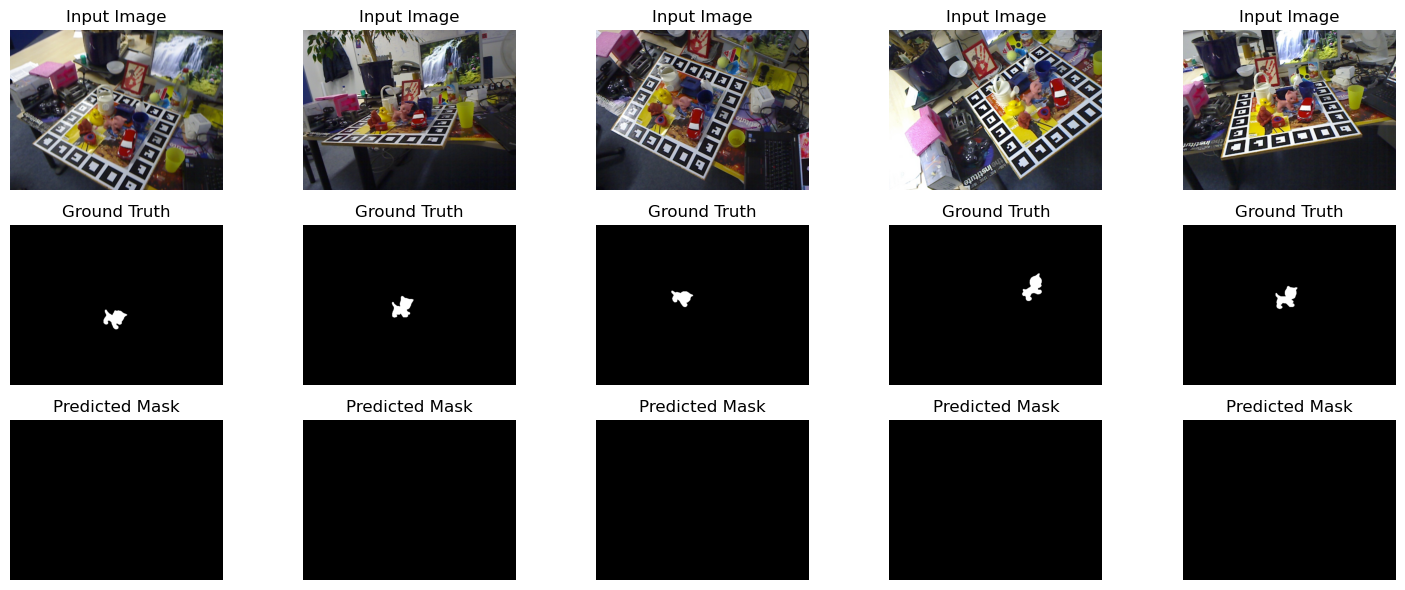

In [17]:
import matplotlib.pyplot as plt
import torch
import random

def visualize_predictions(model, test_loader, num_to_show=5, device='cuda' if torch.cuda.is_available() else 'cpu'):
    model.eval()
    model.to(device)

    with torch.no_grad():
        for images, masks in test_loader:
            images = images.to(device)
            masks = masks.to(device)
            preds = model(images)

            if isinstance(preds, list):  # For multi-head models
                preds = preds[0]  # assuming the first output is the mask

            preds = torch.sigmoid(preds)  # Ensure sigmoid activation for BCELoss
            preds = (preds > 0.01).float()  # Threshold to get binary mask
            break  # use only one batch

    indices = random.sample(range(images.size(0)), num_to_show)
    plt.figure(figsize=(15, 6))

    for i, idx in enumerate(indices):
        img = images[idx].cpu().permute(1, 2, 0).numpy()
        gt_mask = masks[idx].squeeze().cpu().numpy()
        pred_mask = preds[idx].squeeze().cpu().numpy()

        # RGB image
        plt.subplot(3, num_to_show, i + 1)
        plt.imshow(img)
        plt.title("Input Image")
        plt.axis("off")

        # Ground truth mask
        plt.subplot(3, num_to_show, i + 1 + num_to_show)
        plt.imshow(gt_mask, cmap='gray')
        plt.title("Ground Truth")
        plt.axis("off")

        # Predicted mask
        plt.subplot(3, num_to_show, i + 1 + 2 * num_to_show)
        plt.imshow(pred_mask, cmap='gray')
        plt.title("Predicted Mask")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

# Usage
visualize_predictions(model, test_loader, num_to_show=5)


In [18]:
import torch

def load_best_model(model, checkpoint_path, device=None):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device)
    model.eval()  # Optional: set to eval mode if using for inference

    print(f"Loaded model from checkpoint at epoch {checkpoint['epoch'] + 1}, best_val_loss: {checkpoint['best_val_loss']:.4f}")
    return model
model = UNet(out_vectors=False, out_classes=True)

checkpoint_path = "logs/unet_model_checkpoint.pt"
model = load_best_model(model, checkpoint_path)


Loaded model from checkpoint at epoch 19, best_val_loss: 0.0081


# MASK RCNN

In [22]:
import os
import numpy as np
import torch
import torchvision
from torchvision.models.detection import maskrcnn_resnet50_fpn
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import torchvision.transforms as T

class LinemodMaskRCNNDataset(Dataset):
    def __init__(self, base_path, file_list, transforms=None):
        self.rgb_folder = os.path.join(base_path, "rgb")
        self.mask_folder = os.path.join(base_path, "mask")
        self.filenames = file_list
        self.transforms = transforms

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        fname = self.filenames[idx]
        rgb_path = os.path.join(self.rgb_folder, fname + ".png")
        mask_path = os.path.join(self.mask_folder, fname + ".png")

        img = Image.open(rgb_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        img = self.transforms(img) if self.transforms else T.ToTensor()(img)
        mask_np = np.array(mask)
        mask_bin = (mask_np > 0).astype(np.uint8)

        if mask_bin.sum() == 0:
            # Avoid empty masks that will break Mask R-CNN
            raise ValueError(f"Empty mask in file: {mask_path}")

        # Find bounding box
        pos = np.where(mask_bin)
        xmin, xmax = np.min(pos[1]), np.max(pos[1])
        ymin, ymax = np.min(pos[0]), np.max(pos[0])
        boxes = torch.tensor([[xmin, ymin, xmax, ymax]], dtype=torch.float32)

        labels = torch.tensor([1], dtype=torch.int64)  # only one object class
        masks = torch.tensor(mask_bin[None, :, :], dtype=torch.uint8)  # shape: (1, H, W)
        image_id = torch.tensor([idx])
        area = (xmax - xmin) * (ymax - ymin)
        iscrowd = torch.tensor([0], dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels,
            "masks": masks,
            "image_id": image_id,
            "area": torch.tensor([area]),
            "iscrowd": iscrowd
        }

        return img, target
train_dataset = LinemodMaskRCNNDataset(base_path, train_fnames, transforms=transform_rgb)
val_dataset = LinemodMaskRCNNDataset(base_path, test_fnames, transforms=transform_rgb)

train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True, collate_fn=lambda x: tuple(zip(*x)))
val_loader = DataLoader(val_dataset, batch_size=2, shuffle=False, collate_fn=lambda x: tuple(zip(*x)))


model = maskrcnn_resnet50_fpn(pretrained=True)
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(in_features, 2)
in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
hidden_layer = 256
model.roi_heads.mask_predictor = torchvision.models.detection.mask_rcnn.MaskRCNNPredictor(
    in_features_mask, hidden_layer, 2)

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model.to(device)

# ---- Optimizer ---- #
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

# ---- Training Loop ---- #
num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    for images, targets in train_loader:
        images = list(img.to(device) for img in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

    lr_scheduler.step()
    print(f"Epoch {epoch+1}: Loss = {losses.item():.4f}")

# Save model
torch.save(model.state_dict(), "mask_rcnn.pth")

Epoch 1: Loss = 0.2244
Epoch 2: Loss = 0.1010
Epoch 3: Loss = 0.1046
Epoch 4: Loss = 0.0872
Epoch 5: Loss = 0.0989
Epoch 6: Loss = 0.0933
Epoch 7: Loss = 0.0951
Epoch 8: Loss = 0.0901
Epoch 9: Loss = 0.0894
Epoch 10: Loss = 0.0864


/opt/conda/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /home/bradhakrishnan/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 148MB/s]


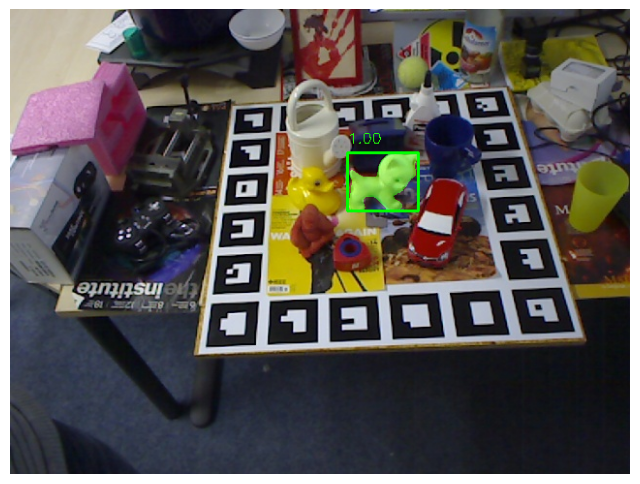

In [25]:
import torch
import torchvision
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import torchvision.transforms.functional as F
import numpy as np
import cv2

# Load the dataset class (reuse your class)
# from your_module import LinemodMaskRCNNDataset

# --- Config ---
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

# Re-create model
model = torchvision.models.detection.maskrcnn_resnet50_fpn(pretrained=False)
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(in_features, 2)
in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
hidden_layer = 256
model.roi_heads.mask_predictor = torchvision.models.detection.mask_rcnn.MaskRCNNPredictor(
    in_features_mask, hidden_layer, 2)

# Load weights
model.load_state_dict(torch.load("mask_rcnn.pth", map_location=device))
model.to(device)
model.eval()

# --- Dataloader for Validation ---
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False, collate_fn=lambda x: tuple(zip(*x)))

# --- Inference on one image ---
def show_prediction(image, pred, threshold=0.5):
    image_np = image.mul(255).permute(1, 2, 0).byte().cpu().numpy()
    image_cv = image_np.copy()

    for i in range(len(pred["boxes"])):
        score = pred["scores"][i].item()
        if score < threshold:
            continue
        box = pred["boxes"][i].detach().cpu().numpy().astype(np.int32)
        mask = pred["masks"][i, 0].detach().cpu().numpy()
        mask = (mask > 0.5).astype(np.uint8)

        # Apply mask
        colored_mask = np.zeros_like(image_cv)
        colored_mask[:, :, 1] = mask * 255  # Green mask
        image_cv = cv2.addWeighted(image_cv, 1.0, colored_mask, 0.5, 0)

        # Draw box
        cv2.rectangle(image_cv, (box[0], box[1]), (box[2], box[3]), (0, 255, 0), 2)

        # Add score text
        cv2.putText(image_cv, f"{score:.2f}", (box[0], box[1] - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (36,255,12), 1)

    # Show result
    plt.figure(figsize=(8, 8))
    plt.imshow(image_cv)
    plt.axis('off')
    plt.show()


# --- Run on one sample ---
with torch.no_grad():
    for images, targets in val_loader:
        image = images[0].to(device)
        pred = model([image])[0]
        show_prediction(image, pred)
        break  # remove this if you want to loop over all


# PVNET stuff

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# Custom SmoothL1 (Huber) Loss with fixed delta
class SmoothL1Custom(nn.Module):
    def __init__(self, delta=0.5):
        super(SmoothL1Custom, self).__init__()
        self.delta = delta

    def forward(self, y_pred, y_true):
        abs_diff = torch.abs(y_true - y_pred)
        loss = torch.where(
            abs_diff < self.delta,
            0.5 * abs_diff ** 2,
            self.delta * (abs_diff - 0.5 * self.delta)
        )
        return loss.sum()

# Basic conv block like convLayer()
class ConvLayer(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, dilation=1):
        super(ConvLayer, self).__init__()
        padding = dilation if kernel_size == 3 else 0
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride,
                              padding=padding, dilation=dilation, bias=False)
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        return self.relu(self.bn(self.conv(x)))

# Coordinate output layer: 18 channels (9 keypoints × 2)
def coordsOutput(x):
    return nn.Conv2d(x.shape[1], 18, kernel_size=1, padding=0)(x)

# Class output layer: 1 channel + batch norm + relu
class ClassOutput(nn.Module):
    def __init__(self, in_channels):
        super(ClassOutput, self).__init__()
        self.class_conv = nn.Conv2d(in_channels, 1, kernel_size=1, padding=0)
        self.bn = nn.BatchNorm2d(1)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        return self.relu(self.bn(self.class_conv(x)))

# Main network
class STVNetNew(nn.Module):
    def __init__(self, out_vectors=True, out_classes=True):
        super(STVNetNew, self).__init__()
        self.out_vectors = out_vectors
        self.out_classes = out_classes

        # Initial layer
        self.init_conv = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, padding='same'),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )

        self.pool1 = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # Res Block 1
        self.block1_conv1 = ConvLayer(64, 64)
        self.block1_conv2 = ConvLayer(64, 64)
        self.block1_conv3 = ConvLayer(64, 64)
        self.block1_conv4 = ConvLayer(64, 64)

        # Res Block 2
        self.block2_down = ConvLayer(64, 128, stride=2)
        self.block2_conv1 = ConvLayer(128, 128)
        self.block2_conv2 = ConvLayer(128, 128)
        self.block2_conv3 = ConvLayer(128, 128)
        self.block2_conv4 = ConvLayer(128, 128)

        # Res Block 3
        self.block3_down = ConvLayer(128, 256, stride=2)
        self.block3_conv1 = ConvLayer(256, 256)
        self.block3_conv2 = ConvLayer(256, 256)
        self.block3_conv3 = ConvLayer(256, 256)
        self.block3_conv4 = ConvLayer(256, 256)

        # Dilated conv block (Res Block 4)
        self.block4_conv1 = ConvLayer(256, 512, dilation=2)
        self.block4_conv2 = ConvLayer(512, 512, dilation=2)
        self.block4_conv3 = ConvLayer(512, 512, dilation=2)
        self.block4_conv4 = ConvLayer(512, 512, dilation=2)

        # Decoder
        self.decoder_256a = ConvLayer(512, 256)
        self.decoder_256b = ConvLayer(256, 256)
        self.decoder_128 = ConvLayer(256, 128)
        self.decoder_64 = ConvLayer(128, 64)
        self.decoder_32 = ConvLayer(64, 32)

        # Output heads
        if self.out_vectors:
            self.vector_out = nn.Conv2d(32, 18, kernel_size=1)
        if self.out_classes:
            self.class_out = ClassOutput(32)

    def forward(self, x):
        x = x.float() / 255.0
        res1 = self.init_conv(x)
        x = self.pool1(res1)

        # Res block 1
        skip = x
        x = self.block1_conv1(x)
        x = self.block1_conv2(x)
        x = x + skip
        skip = x
        x = self.block1_conv3(x)
        x = self.block1_conv4(x)
        x = x + skip
        res2 = x

        # Res block 2
        x = self.block2_down(x)
        skip = x
        x = self.block2_conv1(x)
        x = self.block2_conv2(x)
        x = x + skip
        skip = x
        x = self.block2_conv3(x)
        x = self.block2_conv4(x)
        x = x + skip
        res3 = x

        # Res block 3
        x = self.block3_down(x)
        skip = x
        x = self.block3_conv1(x)
        x = self.block3_conv2(x)
        x = x + skip
        skip = x
        x = self.block3_conv3(x)
        x = self.block3_conv4(x)
        x = x + skip
        res4 = x

        # Res block 4 with dilation
        skip = x
        x = self.block4_conv1(x)
        x = self.block4_conv2(x)
        x = x + skip
        skip = x
        x = self.block4_conv3(x)
        x = self.block4_conv4(x)
        x = x + skip

        # Decoder
        x = self.decoder_256a(x)
        x = self.decoder_256b(x)
        x = x + res4
        x = F.interpolate(x, scale_factor=2, mode='bilinear', align_corners=False)

        x = self.decoder_128(x)
        x = x + res3
        x = F.interpolate(x, scale_factor=2, mode='bilinear', align_corners=False)

        x = self.decoder_64(x)
        x = x + res2
        x = F.interpolate(x, scale_factor=2, mode='bilinear', align_corners=False)

        x = x + res1
        x = self.decoder_32(x)

        outputs = []
        if self.out_vectors:
            outputs.append(self.vector_out(x))
        if self.out_classes:
            outputs.append(self.class_out(x))

        return outputs if len(outputs) > 1 else outputs[0]


In [2]:
from torch.utils.data import Dataset
import numpy as np
import cv2, os, random
from PIL import Image
import math

def getMasterList(basePath):  # returns list with image, mask, and label filenames
    imageList = os.listdir(os.path.join(basePath, 'JPEGImages'))
    maskList = os.listdir(os.path.join(basePath, 'mask'))
    labelList = os.listdir(os.path.join(basePath, 'labels'))
    
    if len(imageList) != len(maskList) or len(imageList) != len(labelList):
        raise Exception("image, mask, and label list lengths do not match.")
    
    return [[a, b, c] for a, b, c in zip(imageList, maskList, labelList)]

def setTrainingPixel(outImage, y, x, labels, height, width):
    for i in range(9):
        yDiff = height * float(labels[i * 2 + 1]) - y
        xDiff = width * float(labels[i * 2]) - x
        mag = math.sqrt(yDiff ** 2 + xDiff ** 2)
        outImage[y][x][i * 2 + 1] = yDiff / mag
        outImage[y][x][i * 2] = xDiff / mag

def filePathToArray(filePath, height=480, width=640):
    image = Image.open(filePath)
    image = image.resize((width, height))
    return np.array(image)



class CoordTrainingDataset(Dataset):
    def __init__(self, modelClass, masterList=None, height=480, width=640, augmentation=False, altLabels=False):
        self.basePath = f'/home/bradhakrishnan/Project/LINEMOD/{modelClass}'
        

        if masterList is None:
            masterList = getMasterList(self.basePath)
            random.shuffle(masterList)
        self.masterList = masterList
        self.height = height
        self.width = width
        self.augmentation = augmentation
        self.altLabels = altLabels

    def __len__(self):
        return len(self.masterList)

    def __getitem__(self, idx):
        item = self.masterList[idx]
        x = filePathToArray(f'{self.basePath}/JPEGImages/{item[0]}', self.height, self.width)
        modelMask = filePathToArray(f'{self.basePath}/mask/{item[1]}', self.height, self.width)

        with open(f"{self.basePath}/{'altLabels' if self.altLabels else 'labels'}/{item[2]}", 'r') as f:
            labels = f.readline().split(' ')[1:19]
            labels = list(map(float, labels))

        if self.augmentation:
            if random.choice([True, False]):
                x = np.flipud(x)
                modelMask = np.flipud(modelMask)
                for i in range(9):
                    labels[i * 2 + 1] = 1 - labels[i * 2 + 1]
            if random.choice([True, False]):
                x = np.fliplr(x)
                modelMask = np.fliplr(modelMask)
                for i in range(9):
                    labels[i * 2] = 1 - labels[i * 2]

        yCoords = np.zeros((self.height, self.width, 18), dtype=np.float32)
        modelCoords = np.where(modelMask == 255)
        for y, x_ in zip(modelCoords[0][::3], modelCoords[1][::3]):
            setTrainingPixel(yCoords, y, x_, labels, self.height, self.width)

        x = torch.tensor(x.transpose(2, 0, 1), dtype=torch.float32)
        y = torch.tensor(yCoords.transpose(2, 0, 1), dtype=torch.float32)

        return x, y


import torch
from torch.utils.data import DataLoader
from tqdm import tqdm

# Model, loss, optimizer
model = StvNetNew(out_vectors=True, out_classes=False) # Instantiate the model on CPU first
model.cuda() 
loss_fn = SmoothL1Custom()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# Dataset and loader
train_dataset = CoordTrainingDataset('cat', masterList=None)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=4)

# Training loop
epochs = 50
for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    for i, (images, targets) in enumerate(tqdm(train_loader)):
        images, targets = images.cuda(), targets.cuda()

        preds = model(images)
        loss = loss_fn(preds, targets)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    print(f"[Epoch {epoch+1}/{epochs}] Loss: {epoch_loss / len(train_loader):.4f}")

  0%|          | 0/148 [00:04<?, ?it/s]


RuntimeError: Input type (torch.cuda.FloatTensor) and weight type (torch.FloatTensor) should be the same

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
class SmoothL1Custom(nn.Module):
    def __init__(self, delta=0.5):
        super(SmoothL1Custom, self).__init__()
        self.delta = delta

    def forward(self, y_pred, y_true):
        abs_diff = torch.abs(y_true - y_pred)
        loss = torch.where(
            abs_diff < self.delta,
            0.5 * abs_diff ** 2,
            self.delta * (abs_diff - 0.5 * self.delta)
        )
        return loss.sum()


# Helper function equivalent to Keras's convLayer
def convLayer(x, filters, kernel_size, strides=1, dilation=1):
    # Calculate padding for 'same' behavior in PyTorch
    if strides > 1:
        calculated_padding = kernel_size // 2
    else:
        calculated_padding = (kernel_size - 1) // 2

    if dilation > 1:
        calculated_padding = dilation * (kernel_size - 1) // 2
    
    x = nn.Conv2d(x.shape[1], filters, kernel_size, stride=strides, padding=calculated_padding, dilation=dilation)(x)
    x = nn.BatchNorm2d(filters)(x)
    x = nn.ReLU()(x)
    return x

# Assuming these are your custom output layers
class CoordsOutput(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, 2, 1) # Assuming 2D coordinates (x, y)
    
    def forward(self, x):
        return self.conv(x)

class ClassOutput(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, 1, 1) # Assuming binary classification per pixel
        self.sigmoid = nn.Sigmoid() 
    
    def forward(self, x):
        return self.sigmoid(self.conv(x))


class StvNetNew(nn.Module):
    def __init__(self, input_shape=(3, 480, 640), out_vectors=True, out_classes=True):
        super().__init__()
        self.out_vectors = out_vectors
        self.out_classes = out_classes

        # Initial layer
        self.conv1 = nn.Conv2d(input_shape[0], 64, 7, padding=3)
        nn.init.xavier_uniform_(self.conv1.weight, gain=nn.init.calculate_gain('relu'))
        self.bn1 = nn.BatchNorm2d(64)
        self.relu1 = nn.ReLU()

        self.maxpool1 = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        self.conv_block1_1 = nn.Sequential(
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )
        self.conv_block1_2 = nn.Sequential(
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )

        self.proj_skip1 = nn.Conv2d(64, 128, 1) 

        self.conv_block2_1 = nn.Sequential(
            nn.Conv2d(64, 128, 3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )
        self.conv_block2_2 = nn.Sequential(
            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )

        self.proj_skip2 = nn.Conv2d(128, 256, 1)

        self.conv_block3_1 = nn.Sequential(
            nn.Conv2d(128, 256, 3, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU()
        )
        self.conv_block3_2 = nn.Sequential(
            nn.Conv2d(256, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU()
        )
        
        self.proj_skip3 = nn.Conv2d(256, 512, 1)


        self.conv_block4_1 = nn.Sequential(
            nn.Conv2d(256, 512, 3, padding=2, dilation=2),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Conv2d(512, 512, 3, padding=2, dilation=2),
            nn.BatchNorm2d(512),
            nn.ReLU()
        )
        self.conv_block4_2 = nn.Sequential(
            nn.Conv2d(512, 512, 3, padding=2, dilation=2),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Conv2d(512, 512, 3, padding=2, dilation=2),
            nn.BatchNorm2d(512),
            nn.ReLU()
        )
        
        self.up1_conv = nn.Sequential(
            nn.Conv2d(512, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU()
        )
        
        # 1x1 convolutions for skip connections to match channels in the decoder
        self.res4_proj = nn.Conv2d(256, 256, 1) # res4: 256 channels -> match x: 256 channels
        self.res3_proj = nn.Conv2d(128, 128, 1) # res3: 128 channels -> match x: 128 channels
        self.res2_proj = nn.Conv2d(64, 64, 1)   # res2: 64 channels -> match x: 64 channels
        self.res1_proj = nn.Conv2d(64, 32, 1)   # res1: 64 channels -> match x: 32 channels


        self.up2_conv = nn.Sequential(
            nn.Conv2d(256, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )

        self.up3_conv = nn.Sequential(
            nn.Conv2d(128, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )
        
        self.up4_conv = nn.Sequential(
            nn.Conv2d(64, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU()
        )
        
        self.upsample = nn.Upsample(scale_factor=2, mode='nearest')

        if out_vectors:
            self.coords_output = CoordsOutput(32)
        if out_classes:
            self.class_output = ClassOutput(32)

    def forward(self, x_in):
        # Lambda layer equivalent
        x = x_in.float() / 255.0

        x = self.relu1(self.bn1(self.conv1(x)))
        res1 = x

        x = self.maxpool1(x)
        skip = x

        x = self.conv_block1_1(x)
        x = x + skip
        skip = x

        x = self.conv_block1_2(x)
        x = x + skip
        
        skip = self.maxpool1(x) 
        skip = self.proj_skip1(skip) 
        res2 = x

        x = self.conv_block2_1(x) 
        x = x + skip
        skip = x

        x = self.conv_block2_2(x)
        x = x + skip
        
        skip = self.maxpool1(x) 
        skip = self.proj_skip2(skip)
        res3 = x

        x = self.conv_block3_1(x) 
        x = x + skip
        skip = x

        x = self.conv_block3_2(x)
        x = x + skip
        
        skip = self.proj_skip3(x)
        res4 = x

        x = self.conv_block4_1(x) 
        x = x + skip
        skip = x

        x = self.conv_block4_2(x)
        x = x + skip

        # DECODER PATH
        x = self.up1_conv(x) # output 256 channels
        
        x = self.upsample(x)
        # Match res4 channels and spatial size
        res4_processed = self.res4_proj(res4) # Project res4 channels to 256
        if x.shape[2:] != res4_processed.shape[2:]:
             x = F.interpolate(x, size=res4_processed.shape[2:], mode='nearest')
        x = x + res4_processed 
        
        x = self.up2_conv(x) # output 128 channels
        x = self.upsample(x)
        # Match res3 channels and spatial size
        res3_processed = self.res3_proj(res3) # Project res3 channels to 128
        if x.shape[2:] != res3_processed.shape[2:]:
             x = F.interpolate(x, size=res3_processed.shape[2:], mode='nearest')
        x = x + res3_processed

        x = self.up3_conv(x) # output 64 channels
        x = self.upsample(x)
        # Match res2 channels and spatial size
        res2_processed = self.res2_proj(res2) # Project res2 channels to 64
        if x.shape[2:] != res2_processed.shape[2:]:
             x = F.interpolate(x, size=res2_processed.shape[2:], mode='nearest')
        x = x + res2_processed

        x = self.up4_conv(x) # output 32 channels
        x = self.upsample(x)
        # Match res1 channels and spatial size
        res1_processed = self.res1_proj(res1) # Project res1 channels to 32
        if x.shape[2:] != res1_processed.shape[2:]:
             x = F.interpolate(x, size=res1_processed.shape[2:], mode='nearest')
        x = x + res1_processed
        
        # Final conv layer
        x = convLayer(x, 32, 3)

        outputs = []
        if self.out_vectors:
            outputs.append(self.coords_output(x))
        if self.out_classes:
            outputs.append(self.class_output(x))
        
        if len(outputs) == 1:
            return outputs[0]
        return tuple(outputs)

# Example usage:
if __name__ == '__main__':
    # Input shape: (Batch, Channels, Height, Width)
    input_tensor = torch.randint(0, 256, (1, 3, 480, 640), dtype=torch.uint8) 

    model = StvNetNew(input_shape=(3, 480, 640), out_vectors=True, out_classes=True)
    
    # Forward pass
    output_vectors, output_classes = model(input_tensor)
    
    print("Output vectors shape:", output_vectors.shape)
    print("Output classes shape:", output_classes.shape)

    model_no_vectors = StvNetNew(input_shape=(3, 480, 640), out_vectors=False, out_classes=True)
    output_only_classes = model_no_vectors(input_tensor)
    print("Output only classes shape:", output_only_classes.shape)

    model_no_classes = StvNetNew(input_shape=(3, 480, 640), out_vectors=True, out_classes=False)
    output_only_vectors = model_no_classes(input_tensor)
    print("Output only vectors shape:", output_only_vectors.shape)
    
    # Check total parameters
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total trainable parameters: {total_params}")

Output vectors shape: torch.Size([1, 2, 480, 640])
Output classes shape: torch.Size([1, 1, 480, 640])
Output only classes shape: torch.Size([1, 1, 480, 640])
Output only vectors shape: torch.Size([1, 2, 480, 640])
Total trainable parameters: 13426915


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from torch.utils.data import Dataset, DataLoader
import os, random
from PIL import Image
import math
from tqdm import tqdm # For progress bar

# --- Custom SmoothL1 (Huber) Loss ---
class SmoothL1Custom(nn.Module):
    def __init__(self, delta=0.5):
        super(SmoothL1Custom, self).__init__()
        self.delta = delta

    def forward(self, y_pred, y_true):
        abs_diff = torch.abs(y_true - y_pred)
        loss = torch.where(
            abs_diff < self.delta,
            0.5 * abs_diff ** 2,
            self.delta * (abs_diff - 0.5 * self.delta)
        )
        return loss.mean()

# --- Refactored ConvLayer as a Class (now named ConvBlock) ---
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, strides=1, dilation=1):
        super().__init__()
        # Calculate padding for 'same' behavior in PyTorch
        if strides > 1:
            calculated_padding = kernel_size // 2
        else:
            calculated_padding = (kernel_size - 1) // 2

        if dilation > 1:
            # For dilated convolutions, padding needs to be adjusted
            calculated_padding = dilation * (kernel_size - 1) // 2
        
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, 
                              stride=strides, padding=calculated_padding, dilation=dilation)
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        x = self.relu(x)
        return x

# --- Custom Output Layers ---
class CoordsOutput(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, 18, 1) # Output 18 channels for 9 keypoints (x,y direction vectors)
    
    def forward(self, x):
        return self.conv(x)

class ClassOutput(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, 1, 1) # Assuming binary classification per pixel
        self.sigmoid = nn.Sigmoid() 
    
    def forward(self, x):
        return self.sigmoid(self.conv(x))

# --- StvNetNew Model Definition ---
class StvNetNew(nn.Module):
    def __init__(self, input_shape=(3, 480, 640), out_vectors=True, out_classes=True):
        super().__init__()
        self.out_vectors = out_vectors
        self.out_classes = out_classes

        # Initial layer
        self.conv1 = nn.Conv2d(input_shape[0], 64, 7, padding=3)
        nn.init.xavier_uniform_(self.conv1.weight, gain=nn.init.calculate_gain('relu'))
        self.bn1 = nn.BatchNorm2d(64)
        self.relu1 = nn.ReLU()

        self.maxpool1 = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        self.conv_block1_1 = nn.Sequential(
            ConvBlock(64, 64, 3), 
            ConvBlock(64, 64, 3)  
        )
        self.conv_block1_2 = nn.Sequential(
            ConvBlock(64, 64, 3), 
            ConvBlock(64, 64, 3)  
        )

        self.proj_skip1 = nn.Conv2d(64, 128, 1) 

        self.conv_block2_1 = nn.Sequential(
            ConvBlock(64, 128, 3, strides=2), # Corrected: stride -> strides
            ConvBlock(128, 128, 3) 
        )
        self.conv_block2_2 = nn.Sequential(
            ConvBlock(128, 128, 3), 
            ConvBlock(128, 128, 3) 
        )

        self.proj_skip2 = nn.Conv2d(128, 256, 1)

        self.conv_block3_1 = nn.Sequential(
            ConvBlock(128, 256, 3, strides=2), # Corrected: stride -> strides
            ConvBlock(256, 256, 3) 
        )
        self.conv_block3_2 = nn.Sequential(
            ConvBlock(256, 256, 3), 
            ConvBlock(256, 256, 3) 
        )
        
        self.proj_skip3 = nn.Conv2d(256, 512, 1)


        self.conv_block4_1 = nn.Sequential(
            ConvBlock(256, 512, 3, dilation=2), 
            ConvBlock(512, 512, 3, dilation=2)  
        )
        self.conv_block4_2 = nn.Sequential(
            ConvBlock(512, 512, 3, dilation=2), 
            ConvBlock(512, 512, 3, dilation=2)  
        )
        
        self.up1_conv = nn.Sequential(
            ConvBlock(512, 256, 3), 
            ConvBlock(256, 256, 3)  
        )
        
        # 1x1 convolutions for skip connections to match channels in the decoder
        self.res4_proj = nn.Conv2d(256, 256, 1) 
        self.res3_proj = nn.Conv2d(128, 128, 1) 
        self.res2_proj = nn.Conv2d(64, 64, 1)   
        self.res1_proj = nn.Conv2d(64, 32, 1)   


        self.up2_conv = nn.Sequential(
            ConvBlock(256, 128, 3) 
        )

        self.up3_conv = nn.Sequential(
            ConvBlock(128, 64, 3) 
        )
        
        self.up4_conv = nn.Sequential(
            ConvBlock(64, 32, 3) 
        )
        
        self.upsample = nn.Upsample(scale_factor=2, mode='nearest')

        # Define the final ConvBlock layer as an attribute
        self.final_conv_block = ConvBlock(32, 32, 3) 

        if out_vectors:
            self.coords_output = CoordsOutput(32)
        if out_classes:
            self.class_output = ClassOutput(32)

    def forward(self, x_in):
        x = x_in.float() / 255.0

        x = self.relu1(self.bn1(self.conv1(x)))
        res1 = x

        x = self.maxpool1(x)
        skip = x

        x = self.conv_block1_1(x)
        x = x + skip
        skip = x

        x = self.conv_block1_2(x)
        x = x + skip
        
        skip = self.maxpool1(x) 
        skip = self.proj_skip1(skip) 
        res2 = x

        x = self.conv_block2_1(x) 
        x = x + skip
        skip = x

        x = self.conv_block2_2(x)
        x = x + skip
        
        skip = self.maxpool1(x) 
        skip = self.proj_skip2(skip)
        res3 = x

        x = self.conv_block3_1(x) 
        x = x + skip
        skip = x

        x = self.conv_block3_2(x)
        x = x + skip
        
        skip = self.proj_skip3(x)
        res4 = x

        x = self.conv_block4_1(x) 
        x = x + skip
        skip = x

        x = self.conv_block4_2(x)
        x = x + skip

        # DECODER PATH
        x = self.up1_conv(x) 
        
        x = self.upsample(x)
        res4_processed = self.res4_proj(res4) 
        if x.shape[2:] != res4_processed.shape[2:]:
             x = F.interpolate(x, size=res4_processed.shape[2:], mode='nearest')
        x = x + res4_processed 
        
        x = self.up2_conv(x) 
        x = self.upsample(x)
        res3_processed = self.res3_proj(res3) 
        if x.shape[2:] != res3_processed.shape[2:]:
             x = F.interpolate(x, size=res3_processed.shape[2:], mode='nearest')
        x = x + res3_processed

        x = self.up3_conv(x) 
        x = self.upsample(x)
        res2_processed = self.res2_proj(res2) 
        if x.shape[2:] != res2_processed.shape[2:]:
             x = F.interpolate(x, size=res2_processed.shape[2:], mode='nearest')
        x = x + res2_processed

        x = self.up4_conv(x) 
        x = self.upsample(x)
        res1_processed = self.res1_proj(res1) 
        if x.shape[2:] != res1_processed.shape[2:]:
             x = F.interpolate(x, size=res1_processed.shape[2:], mode='nearest')
        x = x + res1_processed
        
        # Final conv layer
        x = self.final_conv_block(x) 

        outputs = []
        if self.out_vectors:
            outputs.append(self.coords_output(x))
        if self.out_classes:
            outputs.append(self.class_output(x))
        
        if len(outputs) == 1:
            return outputs[0]
        return tuple(outputs)

# --- Dataset Definition (unchanged from previous) ---
def getMasterList(basePath):  # returns list with image, mask, and label filenames
    imageList = os.listdir(os.path.join(basePath, 'JPEGImages'))
    maskList = os.listdir(os.path.join(basePath, 'mask'))
    labelList = os.listdir(os.path.join(basePath, 'labels'))
    
    if len(imageList) != len(maskList) or len(imageList) != len(labelList):
        raise Exception("image, mask, and label list lengths do not match.")
    
    return [[a, b, c] for a, b, c in zip(imageList, maskList, labelList)]

def setTrainingPixel(outImage, y, x, labels, height, width):
    for i in range(9):
        yDiff = height * float(labels[i * 2 + 1]) - y
        xDiff = width * float(labels[i * 2]) - x
        mag = math.sqrt(yDiff ** 2 + xDiff ** 2)
        if mag == 0:
            outImage[y][x][i * 2 + 1] = 0.0
            outImage[y][x][i * 2] = 0.0
        else:
            outImage[y][x][i * 2 + 1] = yDiff / mag
            outImage[y][x][i * 2] = xDiff / mag

def filePathToArray(filePath, height=480, width=640):
    image = Image.open(filePath)
    image = image.resize((width, height))
    return np.array(image)

class CoordTrainingDataset(Dataset):
    def __init__(self, modelClass, masterList=None, height=480, width=640, augmentation=False, altLabels=False):
        self.basePath = f'/home/bradhakrishnan/Project/LINEMOD/{modelClass}'
        
        if masterList is None:
            masterList = getMasterList(self.basePath)
            random.shuffle(masterList)
        self.masterList = masterList
        self.height = height
        self.width = width
        self.augmentation = augmentation
        self.altLabels = altLabels

    def __len__(self):
        return len(self.masterList)

    def __getitem__(self, idx):
        item = self.masterList[idx]
        x = filePathToArray(f'{self.basePath}/JPEGImages/{item[0]}', self.height, self.width)
        modelMask = filePathToArray(f'{self.basePath}/mask/{item[1]}', self.height, self.width)

        with open(f"{self.basePath}/{'altLabels' if self.altLabels else 'labels'}/{item[2]}", 'r') as f:
            labels = f.readline().split(' ')[1:19]
            labels = list(map(float, labels))

        if self.augmentation:
            if random.choice([True, False]):
                x = np.flipud(x)
                modelMask = np.flipud(modelMask)
                for i in range(9):
                    labels[i * 2 + 1] = 1 - labels[i * 2 + 1]
            if random.choice([True, False]):
                x = np.fliplr(x)
                modelMask = np.fliplr(modelMask)
                for i in range(9):
                    labels[i * 2] = 1 - labels[i * 2]

        yCoords = np.zeros((self.height, self.width, 18), dtype=np.float32)
        modelCoords = np.where(modelMask[:, :, 0] == 255) 
        for y, x_ in zip(modelCoords[0][::3], modelCoords[1][::3]): 
            setTrainingPixel(yCoords, y, x_, labels, self.height, self.width)

        x = torch.tensor(x.transpose(2, 0, 1), dtype=torch.float32)
        y = torch.tensor(yCoords.transpose(2, 0, 1), dtype=torch.float32)

        return x, y

# --- Training Loop ---
if __name__ == '__main__':
    # --- Corrected Model, Loss, Optimizer Setup for GPU Training ---
    model = StvNetNew(out_vectors=True, out_classes=False) 
    model.cuda() # Move the model to GPU before initializing the optimizer

    loss_fn = SmoothL1Custom()

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4) 

    # Dataset and loader
    train_dataset = CoordTrainingDataset('cat', masterList=None)
    train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=4)

    # Training loop
    epochs = 20
    for epoch in range(epochs):
        model.train() 
        epoch_loss = 0
        for i, (images, targets) in enumerate(tqdm(train_loader)):
            # Move data to GPU
            images, targets = images.cuda(), targets.cuda()

            # Forward pass
            preds = model(images)
            loss = loss_fn(preds, targets)
            # Backward pass and optimization
            optimizer.zero_grad() 
            loss.backward()       
            optimizer.step()      
            epoch_loss += loss.item()
        print(f"[Epoch {epoch+1}/{epochs}] Loss: {epoch_loss / len(train_loader):.4f}")

100%|██████████| 148/148 [01:35<00:00,  1.55it/s]


[Epoch 1/20] Loss: 0.0119


100%|██████████| 148/148 [02:07<00:00,  1.16it/s]


[Epoch 2/20] Loss: 0.0026


100%|██████████| 148/148 [01:36<00:00,  1.54it/s]


...

[Epoch 18/20] Loss: 0.0007


100%|██████████| 148/148 [01:35<00:00,  1.54it/s]


[Epoch 19/20] Loss: 0.0007


100%|██████████| 148/148 [01:36<00:00,  1.53it/s]

[Epoch 20/20] Loss: 0.0007


In [3]:
torch.save(model.state_dict(), 'stv_torch_model_weights.pth')


In [50]:
import torch
from PIL import Image
import numpy as np
from torchvision import transforms

# 1. Load the model
# model = StvNetNew(out_vectors=True, out_classes=False)
# model.load_state_dict(torch.load("model.pth"))  # adjust path if needed
model.eval()
model.cuda()

# 2. Load and preprocess a single image
def preprocess_image(image_path, height=480, width=640):
    image = Image.open(image_path).convert("RGB")
    image = image.resize((width, height))
    image = np.array(image).astype(np.float32)
    image = torch.tensor(image.transpose(2, 0, 1))   # (C, H, W)
    image = image.unsqueeze(0)  # Add batch dimension => (1, C, H, W)
    return image.cuda()

# 3. Pass through model
image_path = "/home/bradhakrishnan/Project/LINEMOD/cat/JPEGImages/000000.jpg"  # <- Update path
input_tensor = preprocess_image(image_path)
with torch.no_grad():
    vec_pred = model(input_tensor)

# 4. Use prediction (example: just print shape)
print("Prediction shape:", vec_pred.shape)  # (1, 18, 480, 640)


Prediction shape: torch.Size([1, 18, 480, 640])


In [51]:
import os
import numpy as np
import torch
import torchvision
from torchvision.models.detection import maskrcnn_resnet50_fpn
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import torchvision.transforms as T
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

# Re-create model
rcnn_model = torchvision.models.detection.maskrcnn_resnet50_fpn(pretrained=False)
in_features = rcnn_model.roi_heads.box_predictor.cls_score.in_features
rcnn_model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(in_features, 2)
in_features_mask = rcnn_model.roi_heads.mask_predictor.conv5_mask.in_channels
hidden_layer = 256
rcnn_model.roi_heads.mask_predictor = torchvision.models.detection.mask_rcnn.MaskRCNNPredictor(
    in_features_mask, hidden_layer, 2)

# Load weights
rcnn_model.load_state_dict(torch.load("mask_rcnn.pth", map_location=device))
rcnn_model.to(device)
rcnn_model.eval()

# Image load
img = Image.open(image_path).convert("RGB")

# --- Transform Image ---
transform_rgb = transforms.Compose([
    transforms.ToTensor(),
])
img_tensor = transform_rgb(img).to(device)  # Shape: [C, H, W]

# --- Inference ---
with torch.no_grad():
    prediction = rcnn_model([img_tensor])[0]  # List of one tensor

/opt/conda/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


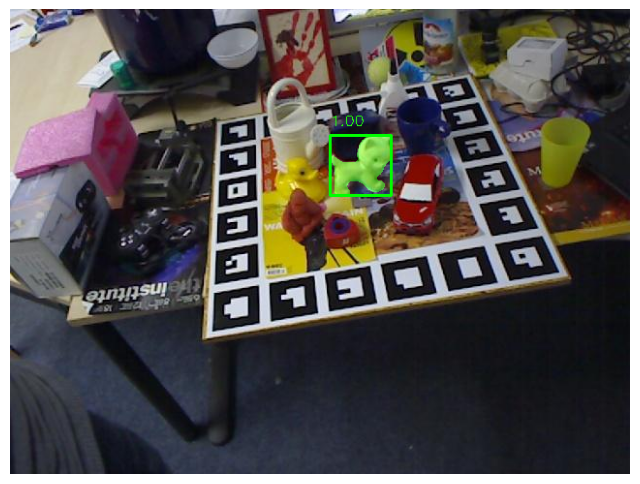

In [52]:
import os
import numpy as np
import torch
import torchvision
from torchvision.models.detection import maskrcnn_resnet50_fpn
from PIL import Image
import torchvision.transforms as transforms
import cv2
import matplotlib.pyplot as plt

def show_prediction(image_tensor, pred, threshold=0.5):
    # Convert image to numpy [H, W, C] and uint8
    image_np = image_tensor.mul(255).permute(1, 2, 0).byte().cpu().numpy()
    image_cv = image_np.copy()

    for i in range(len(pred["boxes"])):
        score = pred["scores"][i].item()
        if score < threshold:
            continue

        box = pred["boxes"][i].detach().cpu().numpy().astype(np.int32)
        mask = pred["masks"][i, 0].detach().cpu().numpy()
        mask = (mask > 0.5).astype(np.uint8)

        # Draw mask
        colored_mask = np.zeros_like(image_cv)
        colored_mask[:, :, 1] = mask * 255  # Green mask
        image_cv = cv2.addWeighted(image_cv, 1.0, colored_mask, 0.5, 0)

        # Draw box
        cv2.rectangle(image_cv, (box[0], box[1]), (box[2], box[3]), (0, 255, 0), 2)

        # Score label
        cv2.putText(image_cv, f"{score:.2f}", (box[0], box[1] - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (36,255,12), 1)

    # Show result
    plt.figure(figsize=(8, 8))
    plt.imshow(image_cv)
    plt.axis('off')
    plt.show()

# --- Show Result ---
show_prediction(img_tensor, prediction)

In [53]:
mask = (prediction['masks'][0, 0] > 0.5).cpu().numpy().astype(np.float32)  # shape [H, W]
vec_pred = vec_pred[0].permute(1, 2, 0).cpu().numpy() 
# Continue with population = np.where(class_pred > 0.9)
population = list(zip(*np.where(mask > 0.9)))
print("Foreground pixels:", len(population))

def ransacVal(y1, x1, v2):
    v2 = v2 / np.linalg.norm(v2)
    return y1 * v2[1] + x1 * v2[0]

hypDict = {i: [] for i in range(9)}  # 8 keypoints + centroid

for _ in range(50):
    if len(population) < 2:
        break
    p1 = population.pop(random.randrange(len(population)))
    p2 = population.pop(random.randrange(len(population)))
    v1 = vec_pred[p1[0], p1[1]]
    v2 = vec_pred[p2[0], p2[1]]
    
    for i in range(9):
        vx1, vy1 = v1[i*2:i*2+2]
        vx2, vy2 = v2[i*2:i*2+2]
        if vx1 == 0 or vx2 == 0 or vx1 == vx2:
            continue
        m1 = vy1 / vx1
        m2 = vy2 / vx2
        if m1 == m2:
            continue
        b1 = p1[0] - m1 * p1[1]
        b2 = p2[0] - m2 * p2[1]
        x = (b2 - b1) / (m1 - m2)
        y = m1 * x + b1
        
        weight = 0
        for voter in population:
            dy, dx = y - voter[0], x - voter[1]
            mag = math.sqrt(dy ** 2 + dx ** 2)
            if mag == 0:
                continue
            unit_dir = np.array([dx / mag, dy / mag])
            vec = vec_pred[voter[0], voter[1], i*2:i*2+2]
            if ransacVal(unit_dir[1], unit_dir[0], vec) > 0.99:
                weight += 1
        
        hypDict[i].append(((y, x), weight))
    population += [p1, p2]

Foreground pixels: 2364


In [54]:
import statistics

def pruneHypsStdDev(hypDict, m=2):
    for key in hypDict:
        hyps = hypDict[key]
        if not hyps:
            continue
        y_vals = [h[0][0] for h in hyps]
        x_vals = [h[0][1] for h in hyps]
        y_mean, x_mean = statistics.mean(y_vals), statistics.mean(x_vals)
        y_dev = statistics.pstdev(y_vals) * m
        x_dev = statistics.pstdev(x_vals) * m
        hypDict[key] = [h for h in hyps if abs(h[0][0] - y_mean) <= y_dev and abs(h[0][1] - x_mean) <= x_dev]

def getMean(hypDict):
    meanDict = {}
    for key, hyps in hypDict.items():
        if not hyps:
            continue
        x_mean = sum(h[0][1] * h[1] for h in hyps) / sum(h[1] for h in hyps)
        y_mean = sum(h[0][0] * h[1] for h in hyps) / sum(h[1] for h in hyps)
        meanDict[key] = [y_mean, x_mean]
    return meanDict

pruneHypsStdDev(hypDict)
meanDict = getMean(hypDict)
print("Mean 2D Keypoints:", meanDict)


Mean 2D Keypoints: {0: [159.48776085269662, 365.51709679201724], 1: [159.8619927590552, 361.58433216048843], 2: [150.72134490780044, 360.742325255853], 3: [163.41675627405596, 373.9565357083591], 4: [150.27682295992142, 357.4819242185614], 5: [202.16071075603023, 339.20765234834636], 6: [171.18295151185407, 352.4579556415738], 7: [161.25487135781316, 355.2627324851214], 8: [155.0469963443192, 386.398509752543]}


In [56]:
def dictToArray(meanDict):
    coordArray = np.zeros((len(meanDict), 2))
    for k, v in meanDict.items():
        coordArray[k] = [v[1], v[0]]  # x, y
    return coordArray

pts3d = np.loadtxt('/home/bradhakrishnan/Project/LINEMOD/cat/farthest.txt')  # (9, 3)

pts2d = dictToArray(meanDict)[1:]  # Ignore centroid

camera_matrix = np.array([[572.4114, 0., 325.2611],
                      [0., 573.57043, 242.04899],
                      [0., 0., 1.]])

success, rvec, tvec = cv2.solvePnP(pts3d, pts2d, camera_matrix, None, flags=cv2.SOLVEPNP_ITERATIVE)
print("Rotation Vector:\n", rvec)
print("Translation Vector:\n", tvec)


Rotation Vector:
 [[-0.5492536 ]
 [-1.28156961]
 [-0.24363265]]
Translation Vector:
 [[-0.00613487]
 [-0.00930553]
 [ 0.00867717]]


Keypoint pixel predictions:
 [[  439.73219984  -971.24998261]
 [  729.31767002 -1537.96531273]
 [ 1867.66628956   141.76490335]
 [ -823.63188332  -502.43170962]
 [ -741.48746064  1066.25755385]
 [  272.47050971  2014.62835485]
 [ -199.1695377    494.03127016]
 [  219.06227254  1255.78635255]]


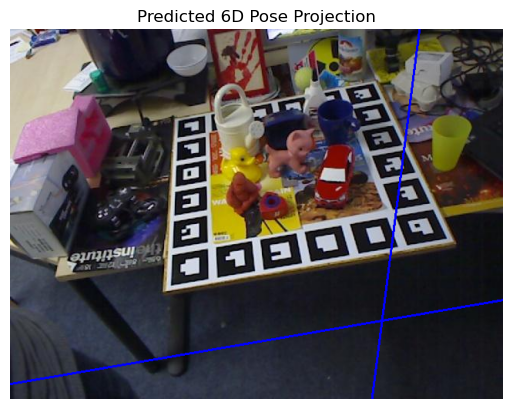

In [57]:
import cv2
import numpy as np

# === Project 3D keypoints to image plane ===
yPred, _ = cv2.projectPoints(pts3d, rvec, tvec, camera_matrix, np.zeros((5,)))  # No distortion
yPred = np.squeeze(yPred)  # shape (8, 2)

print("Keypoint pixel predictions:\n", yPred)

# === Define keypoint labels ===
def labelDrawPoints(drawList):
    return {
        'bld': tuple(map(int, np.round(drawList[0]))),
        'blu': tuple(map(int, np.round(drawList[1]))),
        'fld': tuple(map(int, np.round(drawList[2]))),
        'flu': tuple(map(int, np.round(drawList[3]))),
        'brd': tuple(map(int, np.round(drawList[4]))),
        'bru': tuple(map(int, np.round(drawList[5]))),
        'frd': tuple(map(int, np.round(drawList[6]))),
        'fru': tuple(map(int, np.round(drawList[7]))),
    }

# === Draw the 3D bounding box ===
def drawPose(img, drawPoints, colour=(255, 0, 0)):
    cv2.line(img, drawPoints['bld'], drawPoints['blu'], colour, 2)
    cv2.line(img, drawPoints['bld'], drawPoints['fld'], colour, 2)
    cv2.line(img, drawPoints['bld'], drawPoints['brd'], colour, 2)
    cv2.line(img, drawPoints['blu'], drawPoints['flu'], colour, 2)
    cv2.line(img, drawPoints['blu'], drawPoints['bru'], colour, 2)
    cv2.line(img, drawPoints['fld'], drawPoints['flu'], colour, 2)
    cv2.line(img, drawPoints['fld'], drawPoints['frd'], colour, 2)
    cv2.line(img, drawPoints['flu'], drawPoints['fru'], colour, 2)
    cv2.line(img, drawPoints['fru'], drawPoints['bru'], colour, 2)
    cv2.line(img, drawPoints['fru'], drawPoints['frd'], colour, 2)
    cv2.line(img, drawPoints['frd'], drawPoints['brd'], colour, 2)
    cv2.line(img, drawPoints['brd'], drawPoints['bru'], colour, 2)

# === Draw and show the prediction ===
image = Image.open(image_path).convert("RGB")
img = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2BGR)
drawPose(img, labelDrawPoints(yPred))  # Draw predicted in blue

# === Show the image ===
from matplotlib import pyplot as plt

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title("Predicted 6D Pose Projection")
plt.show()


In [58]:
pts3d

array([[ 0.02178441, -0.05869994, -0.0414618 ],
       [-0.02093567,  0.0655842 ,  0.03955495],
       [ 0.02779895,  0.02978627, -0.04446336],
       [ 0.00139469, -0.05708839,  0.03459186],
       [ 0.01266971,  0.01578414,  0.07163165],
       [-0.032556  , -0.03509996, -0.04010978],
       [-0.02941702,  0.02281759, -0.03967477],
       [ 0.02389689,  0.04313551,  0.03052332]])

# NEW TRY

In [1]:
from torch import nn
import torch
from torch.nn import functional as F
import torch.nn as nn
import math
import torch.utils.model_zoo as model_zoo
import numpy as np
import torch


__all__ = ['ResNet', 'resnet18', 'resnet34', 'resnet50', 'resnet101',
           'resnet152']

model_urls = {
    'resnet18': 'https://download.pytorch.org/models/resnet18-5c106cde.pth',
    'resnet34': 'https://download.pytorch.org/models/resnet34-333f7ec4.pth',
    'resnet50': 'https://download.pytorch.org/models/resnet50-19c8e357.pth',
    'resnet101': 'https://download.pytorch.org/models/resnet101-5d3b4d8f.pth',
    'resnet152': 'https://download.pytorch.org/models/resnet152-b121ed2d.pth',
}


def conv3x3(in_planes, out_planes, stride=1, dilation=1):
    "3x3 convolution with padding"

    kernel_size = np.asarray((3, 3))

    # Compute the size of the upsampled filter with
    # a specified dilation rate.
    upsampled_kernel_size = (kernel_size - 1) * (dilation - 1) + kernel_size

    # Determine the padding that is necessary for full padding,
    # meaning the output spatial size is equal to input spatial size
    full_padding = (upsampled_kernel_size - 1) // 2

    # Conv2d doesn't accept numpy arrays as arguments
    full_padding, kernel_size = tuple(full_padding), tuple(kernel_size)

    return nn.Conv2d(in_planes, out_planes, kernel_size=kernel_size, stride=stride,
                     padding=full_padding, dilation=dilation, bias=False)


class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, inplanes, planes, stride=1, downsample=None, dilation=1):
        super(BasicBlock, self).__init__()
        self.conv1 = conv3x3(inplanes, planes, stride, dilation=dilation)
        self.bn1 = nn.BatchNorm2d(planes)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = conv3x3(planes, planes, dilation=dilation)
        self.bn2 = nn.BatchNorm2d(planes)
        self.downsample = downsample
        self.stride = stride

    def forward(self, x):
        residual = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        if self.downsample is not None:
            residual = self.downsample(x)

        out += residual
        out = self.relu(out)

        return out


class Bottleneck(nn.Module):
    expansion = 4

    def __init__(self, inplanes, planes, stride=1, downsample=None, dilation=1):
        super(Bottleneck, self).__init__()
        self.conv1 = nn.Conv2d(inplanes, planes, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)

        self.conv2 = conv3x3(planes, planes, stride=stride, dilation=dilation)

        # self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=stride,
        #                       padding=1, bias=False)

        self.bn2 = nn.BatchNorm2d(planes)
        self.conv3 = nn.Conv2d(planes, planes * 4, kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm2d(planes * 4)
        self.relu = nn.ReLU(inplace=True)
        self.downsample = downsample
        self.stride = stride

    def forward(self, x):
        residual = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)

        out = self.conv3(out)
        out = self.bn3(out)

        if self.downsample is not None:
            residual = self.downsample(x)

        out += residual
        out = self.relu(out)

        return out


class ResNet(nn.Module):

    def __init__(self,
                 block,
                 layers,
                 num_classes=1000,
                 fully_conv=False,
                 remove_avg_pool_layer=False,
                 output_stride=32):

        # Add additional variables to track
        # output stride. Necessary to achieve
        # specified output stride.
        self.output_stride = output_stride
        self.current_stride = 4
        self.current_dilation = 1

        self.remove_avg_pool_layer = remove_avg_pool_layer

        self.inplanes = 64
        self.fully_conv = fully_conv
        super(ResNet, self).__init__()
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3,
                               bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        self.layer1 = self._make_layer(block, 64, layers[0])
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)

        self.avgpool = nn.AvgPool2d(7)

        self.fc = nn.Linear(512 * block.expansion, num_classes)

        if self.fully_conv:
            self.avgpool = nn.AvgPool2d(7, padding=3, stride=1)
            # In the latest unstable torch 4.0 the tensor.copy_
            # method was changed and doesn't work as it used to be
            # self.fc = nn.Conv2d(512 * block.expansion, num_classes, 1)

        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                n = m.kernel_size[0] * m.kernel_size[1] * m.out_channels
                m.weight.data.normal_(0, math.sqrt(2. / n))
            elif isinstance(m, nn.BatchNorm2d):
                m.weight.data.fill_(1)
                m.bias.data.zero_()

    def _make_layer(self, block, planes, blocks, stride=1, dilation=1):
        downsample = None

        if stride != 1 or self.inplanes != planes * block.expansion:

            # Check if we already achieved desired output stride.
            if self.current_stride == self.output_stride:

                # If so, replace subsampling with a dilation to preserve
                # current spatial resolution.
                self.current_dilation = self.current_dilation * stride
                stride = 1
            else:

                # If not, perform subsampling and update current
                # new output stride.
                self.current_stride = self.current_stride * stride

            # We don't dilate 1x1 convolution.
            downsample = nn.Sequential(
                nn.Conv2d(self.inplanes, planes * block.expansion,
                          kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(planes * block.expansion),
            )

        layers = []
        # self.current_dilation = 1
        layers.append(block(self.inplanes, planes, stride, downsample, dilation=self.current_dilation))
        self.inplanes = planes * block.expansion
        for i in range(1, blocks):
            layers.append(block(self.inplanes, planes, dilation=self.current_dilation))

        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x2s = self.relu(x)
        x = self.maxpool(x2s)

        x4s = self.layer1(x)
        x8s = self.layer2(x4s)
        x16s = self.layer3(x8s)
        x32s = self.layer4(x16s)
        x = x32s

        if not self.remove_avg_pool_layer:
            x = self.avgpool(x)

        if not self.fully_conv:
            x = x.view(x.size(0), -1)

        xfc = self.fc(x)

        return x2s, x4s, x8s, x16s, x32s, xfc


def resnet18(pretrained=False, **kwargs):
    """Constructs a ResNet-18 model.

    Args:
        pretrained (bool): If True, returns a model pre-trained on ImageNet
    """
    model = ResNet(BasicBlock, [2, 2, 2, 2], **kwargs)
    if pretrained:
        model.load_state_dict(model_zoo.load_url(model_urls['resnet18']))
    return model




class Resnet18(nn.Module):
    def __init__(self, ver_dim, seg_dim, fcdim=256, s8dim=128, s4dim=64, s2dim=32, raw_dim=32):
        super(Resnet18, self).__init__()

        # Load the pretrained weights, remove avg pool
        # layer and get the output stride of 8
        resnet18_8s = resnet18(fully_conv=True,
                               pretrained=True,
                               output_stride=8,
                               remove_avg_pool_layer=True)

        self.ver_dim=ver_dim
        self.seg_dim=seg_dim

        # Randomly initialize the 1x1 Conv scoring layer
        resnet18_8s.fc = nn.Sequential(
            nn.Conv2d(resnet18_8s.inplanes, fcdim, 3, 1, 1, bias=False),
            nn.BatchNorm2d(fcdim),
            nn.ReLU(True)
        )
        self.resnet18_8s = resnet18_8s

        # x8s->128
        self.conv8s=nn.Sequential(
            nn.Conv2d(128+fcdim, s8dim, 3, 1, 1, bias=False),
            nn.BatchNorm2d(s8dim),
            nn.LeakyReLU(0.1,True)
        )
        self.up8sto4s=nn.UpsamplingBilinear2d(scale_factor=2)
        # x4s->64
        self.conv4s=nn.Sequential(
            nn.Conv2d(64+s8dim, s4dim, 3, 1, 1, bias=False),
            nn.BatchNorm2d(s4dim),
            nn.LeakyReLU(0.1,True)
        )

        # x2s->64
        self.conv2s=nn.Sequential(
            nn.Conv2d(64+s4dim, s2dim, 3, 1, 1, bias=False),
            nn.BatchNorm2d(s2dim),
            nn.LeakyReLU(0.1,True)
        )
        self.up4sto2s=nn.UpsamplingBilinear2d(scale_factor=2)

        self.convraw = nn.Sequential(
            nn.Conv2d(3+s2dim, raw_dim, 3, 1, 1, bias=False),
            nn.BatchNorm2d(raw_dim),
            nn.LeakyReLU(0.1,True),
            nn.Conv2d(raw_dim, seg_dim+ver_dim, 1, 1)
        )
        self.up2storaw = nn.UpsamplingBilinear2d(scale_factor=2)

    def _normal_initialization(self, layer):
        layer.weight.data.normal_(0, 0.01)
        layer.bias.data.zero_()

    # def decode_keypoint(self, output):
    #     vertex = output['vertex'].permute(0, 2, 3, 1)
    #     b, h, w, vn_2 = vertex.shape
    #     vertex = vertex.view(b, h, w, vn_2//2, 2)
    #     mask = torch.argmax(output['seg'], 1)
    #     if cfg.test.un_pnp:
    #         mean = ransac_voting_layer_v3(mask, vertex, 512, inlier_thresh=0.99)
    #         kpt_2d, var = estimate_voting_distribution_with_mean(mask, vertex, mean)
    #         output.update({'mask': mask, 'kpt_2d': kpt_2d, 'var': var})
    #     else:
    #         kpt_2d = ransac_voting_layer_v3(mask, vertex, 128, inlier_thresh=0.99, max_num=100)
    #         output.update({'mask': mask, 'kpt_2d': kpt_2d})

    def forward(self, x, feature_alignment=False):
        x2s, x4s, x8s, x16s, x32s, xfc = self.resnet18_8s(x)

        fm=self.conv8s(torch.cat([xfc,x8s],1))
        fm=self.up8sto4s(fm)
        if fm.shape[2]==136:
            fm = nn.functional.interpolate(fm, (135,180), mode='bilinear', align_corners=False)

        fm=self.conv4s(torch.cat([fm,x4s],1))
        fm=self.up4sto2s(fm)

        fm=self.conv2s(torch.cat([fm,x2s],1))
        fm=self.up2storaw(fm)

        x=self.convraw(torch.cat([fm,x],1))
        seg_pred=x[:,:self.seg_dim,:,:]
        ver_pred=x[:,self.seg_dim:,:,:]

        ret = {'seg': seg_pred, 'vertex': ver_pred}

        # if not self.training:
        #     with torch.no_grad():
        #         self.decode_keypoint(ret)

        return ret


In [2]:
model = Resnet18(18,2)


In [3]:
import os
import numpy as np
import shutil
from PIL import Image
import json
from lib.csrc.fps import fps_utils
from lib.utils.linemod.opengl_renderer import OpenGLRenderer
from lib.utils import base_utils

def create_dataset_structure(base_path):
    """Create the basic dataset directory structure"""
    directories = ['rgb', 'mask', 'pose']
    for dir_name in directories:
        dir_path = os.path.join(base_path, dir_name)
        os.makedirs(dir_path, exist_ok=True)
    return True

def process_3d_model(model_path, output_path):
    """Process the 3D model file and generate necessary files"""
    # Copy model file
    shutil.copy(model_path, os.path.join(output_path, 'model.ply'))
    
    # Create renderer and get model points
    renderer = OpenGLRenderer(model_path)
    model = renderer.model['pts'] / 1000
    
    # Calculate model corners
    min_x, max_x = np.min(model[:, 0]), np.max(model[:, 0])
    min_y, max_y = np.min(model[:, 1]), np.max(model[:, 1])
    min_z, max_z = np.min(model[:, 2]), np.max(model[:, 2])
    corners_3d = np.array([
        [min_x, min_y, min_z],
        [min_x, min_y, max_z],
        [min_x, max_y, min_z],
        [min_x, max_y, max_z],
        [max_x, min_y, min_z],
        [max_x, min_y, max_z],
        [max_x, max_y, min_z],
        [max_x, max_y, max_z],
    ])
    
    # Calculate diameter
    diameter = np.max(np.linalg.norm(corners_3d[None] - corners_3d[:, None], axis=2))
    
    # Save diameter
    with open(os.path.join(output_path, 'diameter.txt'), 'w') as f:
        f.write(str(diameter))
    
    # Generate and save FPS points
    fps_points = fps_utils.farthest_point_sampling(model, 8)
    np.savetxt(os.path.join(output_path, 'fps.txt'), fps_points)
    
    return corners_3d, fps_points

def save_camera_matrix(K, output_path):
    """Save camera intrinsic matrix"""
    np.savetxt(os.path.join(output_path, 'camera.txt'), K)

def add_image_and_mask(rgb_path, mask_path, pose, dataset_path, index):
    """Add an image, its mask and pose to the dataset"""
    # Copy and rename RGB image
    rgb_out = os.path.join(dataset_path, 'rgb', f'{index}.jpg')
    shutil.copy(rgb_path, rgb_out)
    
    # Copy and rename mask
    mask_out = os.path.join(dataset_path, 'mask', f'{index}.png')
    shutil.copy(mask_path, mask_out)
    
    # Save pose
    pose_out = os.path.join(dataset_path, 'pose', f'pose{index}.npy')
    np.save(pose_out, pose)

def create_coco_annotations(dataset_path, K, corners_3d, fps_3d):
    """Create COCO format annotations"""
    images = []
    annotations = []
    img_id = 0
    ann_id = 0
    
    # Calculate center_3d
    center_3d = (np.max(corners_3d, 0) + np.min(corners_3d, 0)) / 2
    
    rgb_dir = os.path.join(dataset_path, 'rgb')
    pose_dir = os.path.join(dataset_path, 'pose')
    mask_dir = os.path.join(dataset_path, 'mask')
    
    for img_name in sorted(os.listdir(rgb_dir)):
        if not img_name.endswith('.jpg'):
            continue
            
        index = int(os.path.splitext(img_name)[0])
        rgb_path = os.path.join(rgb_dir, img_name)
        
        # Get image info
        img = Image.open(rgb_path)
        img_size = img.size
        img_id += 1
        images.append({
            'file_name': rgb_path,
            'height': img_size[1],
            'width': img_size[0],
            'id': img_id
        })
        
        # Load pose
        pose_path = os.path.join(pose_dir, f'pose{index}.npy')
        pose = np.load(pose_path)
        
        # Project 3D points to 2D
        corner_2d = base_utils.project(corners_3d, K, pose)
        center_2d = base_utils.project(center_3d[None], K, pose)[0]
        fps_2d = base_utils.project(fps_3d, K, pose)
        
        # Create annotation
        mask_path = os.path.join(mask_dir, f'{index}.png')
        ann_id += 1
        anno = {
            'mask_path': mask_path,
            'image_id': img_id,
            'category_id': 1,
            'id': ann_id,
            'corner_3d': corners_3d.tolist(),
            'corner_2d': corner_2d.tolist(),
            'center_3d': center_3d.tolist(),
            'center_2d': center_2d.tolist(),
            'fps_3d': fps_3d.tolist(),
            'fps_2d': fps_2d.tolist(),
            'K': K.tolist(),
            'pose': pose.tolist(),
            'data_root': rgb_dir,
            'type': 'real',
            'cls': 'custom'
        }
        annotations.append(anno)
    
    # Create COCO format dataset
    categories = [{'supercategory': 'none', 'id': 1, 'name': 'custom'}]
    dataset = {
        'images': images,
        'annotations': annotations,
        'categories': categories
    }
    
    # Save annotations
    with open(os.path.join(dataset_path, 'train.json'), 'w') as f:
        json.dump(dataset, f)

def create_pvnet_dataset(base_path, model_path, camera_matrix):
    """
    Create a complete dataset for PVNet training
    
    Args:
        base_path: Path where the dataset will be created
        model_path: Path to the 3D model file (.ply)
        camera_matrix: 3x3 camera intrinsic matrix
    """
    # Create directory structure
    create_dataset_structure(base_path)
    
    # Process 3D model
    corners_3d, fps_3d = process_3d_model(model_path, base_path)
    
    # Save camera matrix
    save_camera_matrix(camera_matrix, base_path)
    
    print(f"""
Dataset structure created at: {base_path}

Please add your training data in the following format:
1. RGB images (.jpg) in the 'rgb' directory
2. Mask images (.png) in the 'mask' directory
3. Pose matrices (.npy) in the 'pose' directory

The following files have been created:
- model.ply: Copy of your 3D model
- camera.txt: Camera intrinsic matrix
- diameter.txt: Object diameter
- fps.txt: Farthest point sampling points

After adding your training data, run:
    create_coco_annotations('{base_path}', camera_matrix, corners_3d, fps_3d)
to generate the COCO format annotations.
""")

ModuleNotFoundError: No module named 'lib'